**Task** : Develop a machine learning model to analyze historical unemployment data and accurately predict future unemployment rates using time-series feature engineering and ensemble learning techniques.


> **Problem Statement**:

The project is to analyze and predict unemployment rates using historical data.
Unemployment is a key economic indicator influenced by multiple factors such as:

* Regional differences
* Labour participation
* Seasonal trends
* External shocks (e.g., COVID-19)

> **Objectives**:

To build a robust machine learning model that can:
* Predict unemployment rate (%)
* Capture temporal (time-based) patterns
* Handle regional variations
* Generalize well to unseen data

> **Dataset Description**

The dataset includes:
* Date → timeline of observations
* Region → state-wise data
* Area → Urban/Rural classification
* Estimated Unemployment Rate (%) → target variable
* Estimated Labour Participation Rate (%) → key feature
* Estimated Employed → employment count
* Frequency → data granularity

> **Importing the Libraries**

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

> **Loading the Dataset**

In [194]:
df = pd.read_csv("Unemployment in India.csv")

In [195]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


> **Exploring the Dataset**

In [196]:
type(df)

pandas.core.frame.DataFrame

In [197]:
df.shape

(768, 7)

In [198]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [199]:
df.columns[5]

' Estimated Labour Participation Rate (%)'

In [200]:
df.sample(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
164,Kerala,31-08-2019,Monthly,10.32,5233449.0,39.90,Rural
422,Chandigarh,31-12-2019,Monthly,8.33,311146.0,35.19,Urban
14,Assam,31-05-2019,Monthly,4.29,11749334.0,57.39,Rural
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban
224,Odisha,31-12-2019,Monthly,4.67,11345069.0,40.91,Rural


In [201]:
df.all

<bound method DataFrame.all of              Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0    Andhra Pradesh   31-05-2019    Monthly                              3.65   
1    Andhra Pradesh   30-06-2019    Monthly                              3.05   
2    Andhra Pradesh   31-07-2019    Monthly                              3.75   
3    Andhra Pradesh   31-08-2019    Monthly                              3.32   
4    Andhra Pradesh   30-09-2019    Monthly                              5.17   
..              ...          ...        ...                               ...   
763             NaN          NaN        NaN                               NaN   
764             NaN          NaN        NaN                               NaN   
765             NaN          NaN        NaN                               NaN   
766             NaN          NaN        NaN                               NaN   
767             NaN          NaN        NaN                               NaN   

      Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0             11999139.0                                     43.24  Rural  
1             11755881.0                                     42.05  Rural  
2             12086707.0                                     43.50  Rural  
3             12285693.0                                     43.97  Rural  
4             12256762.0                                     44.68  Rural  
..                   ...                                       ...    ...  
763                  NaN                                       NaN    NaN  
764                  NaN                                       NaN    NaN  
765                  NaN                                       NaN    NaN  
766                  NaN                                       NaN    NaN  
767                  NaN                                       NaN    NaN  

[768 rows x 7 columns]>

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [203]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [204]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [205]:
df.notnull().sum()

,0
Region,740
Date,740
Frequency,740
Estimated Unemployment Rate (%),740
Estimated Employed,740
Estimated Labour Participation Rate (%),740
Area,740


In [206]:
df['Area'].value_counts()


,count
Area,
Urban,381
Rural,359


In [207]:
df[' Frequency'].value_counts()

,count
Frequency,
Monthly,381
Monthly,359


In [208]:
df['Region'].value_counts()

,count
Region,
Andhra Pradesh,28
Bihar,28
Chhattisgarh,28
Delhi,28
Karnataka,28
Gujarat,28
Haryana,28
Himachal Pradesh,28
Jharkhand,28


> **Data Cleaning**

In [209]:
df.columns = df.columns.str.strip()

In [210]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [212]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [213]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_3636/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [214]:
df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [215]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          768 non-null    float64       
 4   Estimated Employed                       768 non-null    float64       
 5   Estimated Labour Participation Rate (%)  768 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Year                                     740 non-null    float64       
 8   Month                                    740 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(3)


> **Exploratory Data Analysis (EDA)**

In [217]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019.0,5.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019.0,6.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019.0,7.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019.0,8.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019.0,9.0


In [218]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
763,NaN,NaT,NaN,11.787946,7.204460e+06,42.630122,NaN,NaN,NaN
764,NaN,NaT,NaN,11.787946,7.204460e+06,42.630122,NaN,NaN,NaN
765,NaN,NaT,NaN,11.787946,7.204460e+06,42.630122,NaN,NaN,NaN
766,NaN,NaT,NaN,11.787946,7.204460e+06,42.630122,NaN,NaN,NaN
767,NaN,NaT,NaN,11.787946,7.204460e+06,42.630122,NaN,NaN,NaN


> **Visualization**

In [219]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

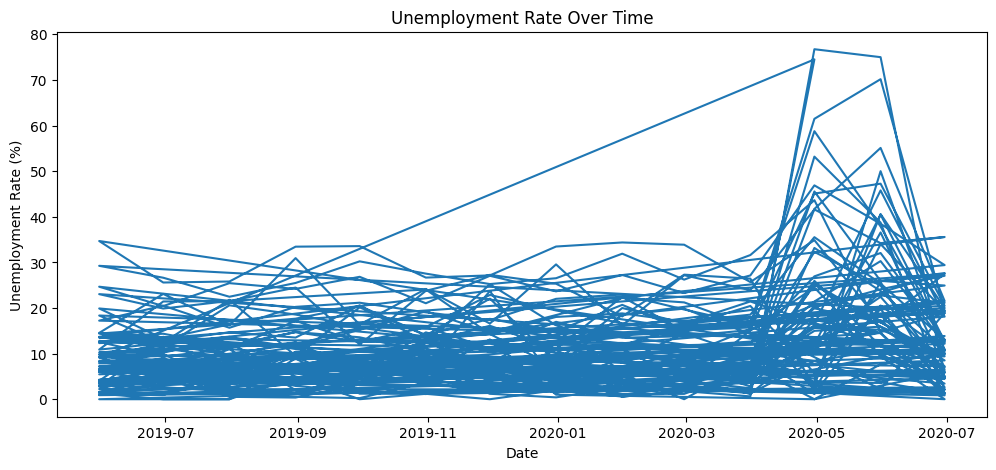

In [220]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

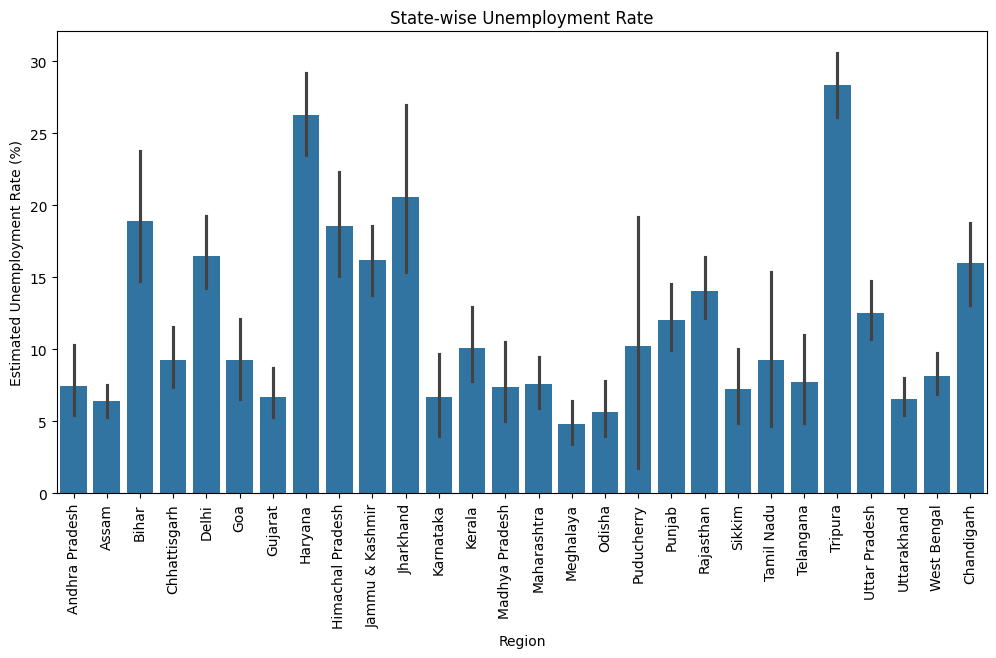

In [221]:
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title("State-wise Unemployment Rate")
plt.show()

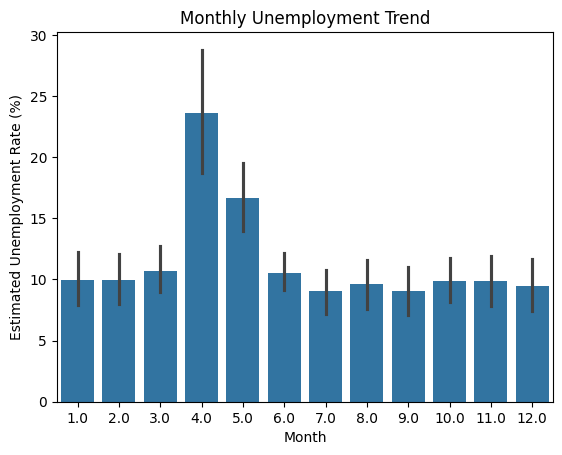

In [222]:
sns.barplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Monthly Unemployment Trend")
plt.show()



*   **Heatmap**


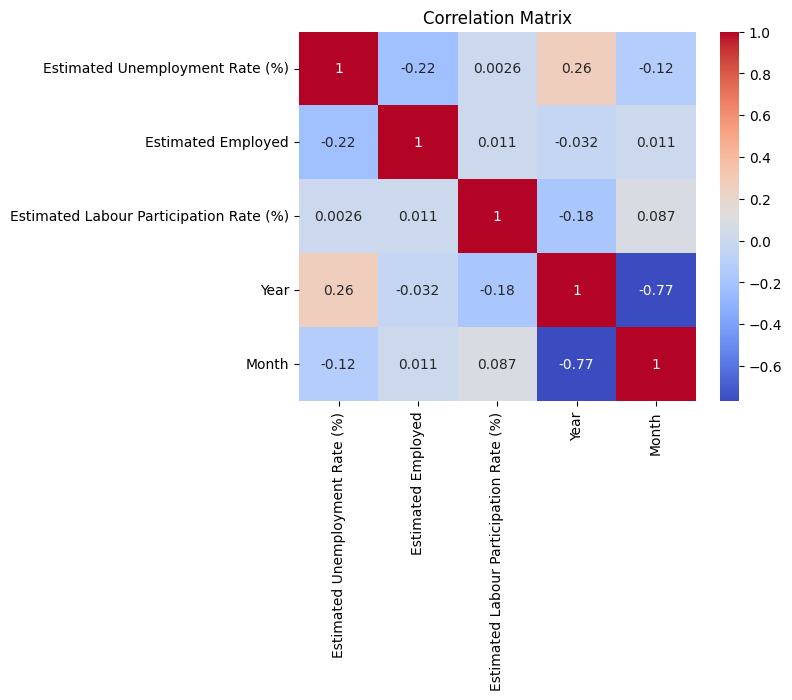

In [223]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [224]:
df = df.dropna(subset=['Year', 'Month'])

In [225]:
df.isna().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0
Year,0
Month,0


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Year                                     740 non-null    float64       
 8   Month                                    740 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memor

> **Data Preparation**

In [227]:
import numpy as np

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

/tmp/ipykernel_3636/2677064368.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
/tmp/ipykernel_3636/2677064368.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


In [228]:
df['Area'] = df['Area'].map({'Urban': 1, 'Rural': 0})

/tmp/ipykernel_3636/2904420406.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Area'] = df['Area'].map({'Urban': 1, 'Rural': 0})


In [229]:
df['Area'].unique()

array([0, 1])

In [230]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Year', 'Month', 'Month_sin', 'Month_cos'],
      dtype='object')


> **Feature Enigineering**

In [231]:
df['lag_1'] = df['Estimated Unemployment Rate (%)'].shift(1)
df['lag_2'] = df['Estimated Unemployment Rate (%)'].shift(2)
df['lag_3'] = df['Estimated Unemployment Rate (%)'].shift(3)

/tmp/ipykernel_3636/245045485.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lag_1'] = df['Estimated Unemployment Rate (%)'].shift(1)
/tmp/ipykernel_3636/245045485.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lag_2'] = df['Estimated Unemployment Rate (%)'].shift(2)
/tmp/ipykernel_3636/245045485.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [232]:

df['diff_1'] = df['Estimated Unemployment Rate (%)'].diff(1)

df['lag_12'] = df['Estimated Unemployment Rate (%)'].shift(12)

df['month_x_area'] = df['Month'] * df['Area']

/tmp/ipykernel_3636/3940882937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['diff_1'] = df['Estimated Unemployment Rate (%)'].diff(1)
/tmp/ipykernel_3636/3940882937.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lag_12'] = df['Estimated Unemployment Rate (%)'].shift(12)
/tmp/ipykernel_3636/3940882937.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [233]:
df['rolling_mean_3'] = df['Estimated Unemployment Rate (%)'].rolling(3).mean()

/tmp/ipykernel_3636/3422748955.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean_3'] = df['Estimated Unemployment Rate (%)'].rolling(3).mean()


In [234]:
X = df.drop([
    'Estimated Unemployment Rate (%)',
    'Date',
    'Frequency'
], axis=1)

y = df['Estimated Unemployment Rate (%)']

In [235]:
X = pd.get_dummies(X, drop_first=True)

> **Data Sliptting**

In [236]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

> **Model Training**

In [237]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,

    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)



RandomForestRegressor(max_depth=15, n_estimators=500, random_state=42)

> **Prediction**

In [238]:
y_pred = rf.predict(X_test)

In [239]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    scores.append(r2_score(y_test, preds))

print("CV R2 Scores:", scores)
print("Average R2:", np.mean(scores))

CV R2 Scores: [0.6609991493016819, 0.8779920108927618, 0.8899801186880073, 0.8377080944119941, 0.9468741864974338]
Average R2: 0.8427107119583758


> **Model Evaluation**

In [240]:
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print("Train:", train_score)
print("Test:", test_score)

Train: 0.985764489293116
Test: 0.9468741864974338


In [241]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9468741864974338
MAE: 1.3484478999095797


> **Testing with samples**

In [242]:
for _ in range(5):
    sample = X_test.sample(1)
    actual = y_test.loc[sample.index]
    pred = rf.predict(sample)

    print("\nPredicted:", pred[0])
    print("Actual:", actual.values[0])


Predicted: 11.321425142857162
Actual: 13.17

Predicted: 7.9189669156954166
Actual: 7.79

Predicted: 2.0905445714285738
Actual: 1.86

Predicted: 14.72761866666668
Actual: 15.22

Predicted: 7.658958280774783
Actual: 7.55


> **Scores & Metrics**

In [243]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9468741864974338
MAE: 1.3484478999095797
RMSE: 2.1910535649242466


> **Visual Representation**

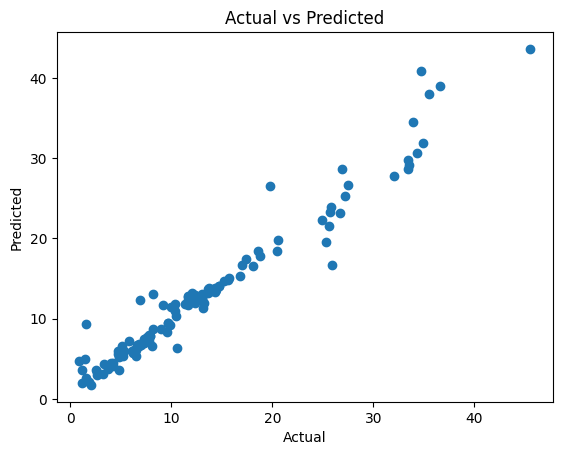

In [244]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()